In [10]:
import pandas as pd
import mysql.connector
import seaborn as sns
import matplotlib.pyplot as plt

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="12345",
    database="spotify_database"
)

query =""" SELECT 
    a.artist_name,
    COUNT(t.track_id) AS number_of_tracks
FROM artists a
LEFT JOIN tracks t 
    ON a.artist_id = t.artist_id
GROUP BY a.artist_id, a.artist_name
ORDER BY number_of_tracks DESC
LIMIT 10;"""

df = pd.read_sql(query, connection)

print(df.head(40))

      artist_name  number_of_tracks
0       Mia Brown                29
1     Ethan Verma                29
2      Aiden King                24
3       Ava Joshi                23
4    Ishaan Joshi                22
5    Aditya Young                22
6   Daniel Martin                20
7  Isabella Brown                20
8       Ava Scott                20
9     Maya Walker                19


C:\Users\rampa\AppData\Local\Temp\ipykernel_16028\3963735969.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


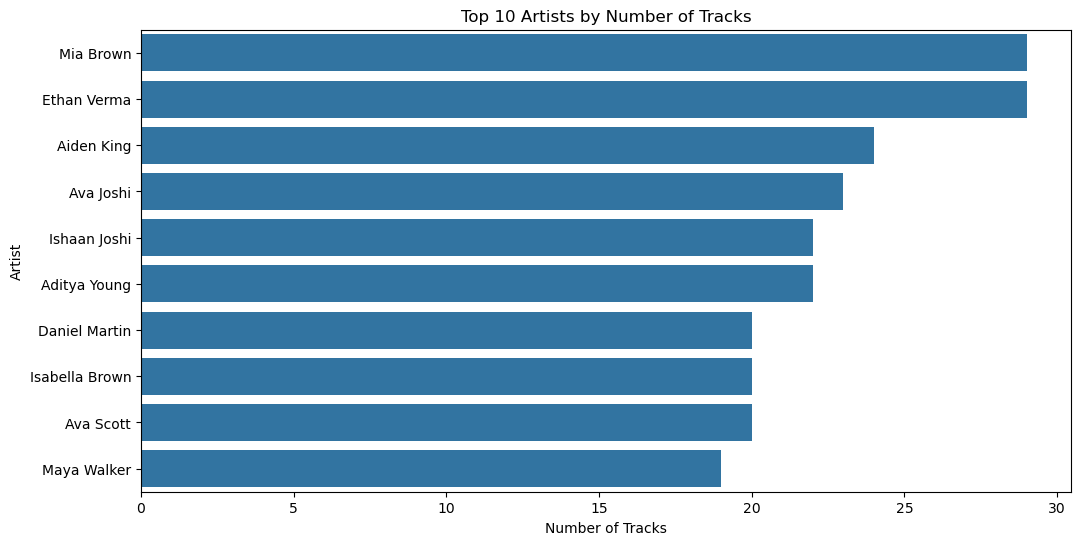

<Figure size 640x480 with 0 Axes>

In [13]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="number_of_tracks",
    y="artist_name"
)

plt.title("Top 10 Artists by Number of Tracks")
plt.xlabel("Number of Tracks")
plt.ylabel("Artist")

plt.show()